# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

import os

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_2068/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

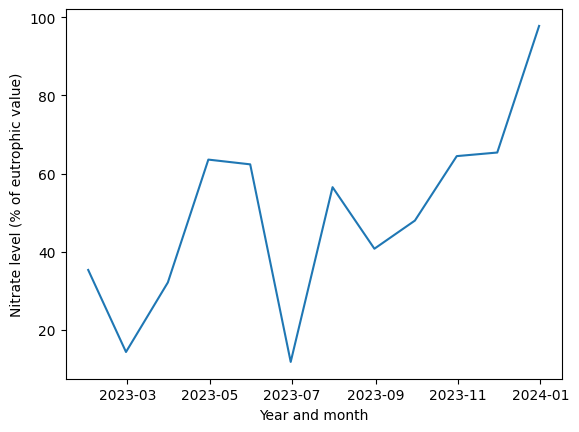

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_2068/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

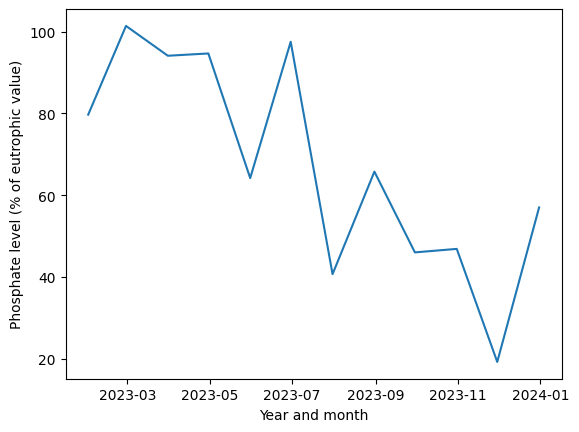

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

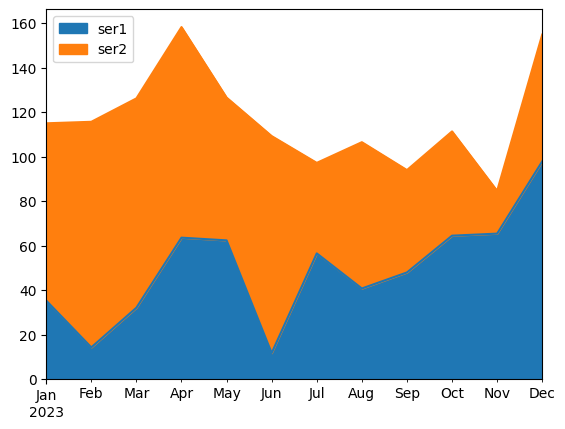

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:

data_path = kagglehub.dataset_download("ericpierce/austinhousingprices")
file = os.path.join(data_path, "austinHousingData.csv")
df = pd.read_csv(file)
print("Austin Housing Data Sample:")
print(df.head())

Austin Housing Data Sample:
         zpid          city          streetAddress  zipcode  \
0   111373431  pflugerville   14424 Lake Victor Dr    78660   
1   120900430  pflugerville     1104 Strickling Dr    78660   
2  2084491383  pflugerville    1408 Fort Dessau Rd    78660   
3   120901374  pflugerville     1025 Strickling Dr    78660   
4    60134862  pflugerville  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  ...  numOfMiddleSchools  \
0             1.98             2            Tru


Highly Correlated Variable Pairs (Above 0.7):
          Feature1                  Feature2  Correlation
1    parkingSpaces              garageSpaces     0.997321
2  avgSchoolRating  MedianStudentsPerTeacher     0.734615


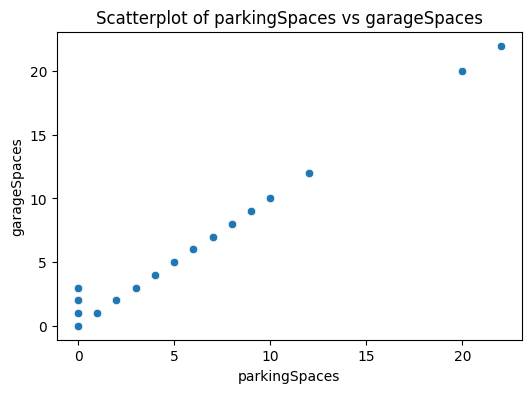

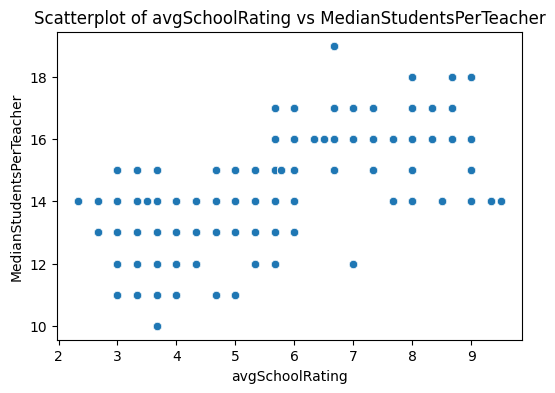

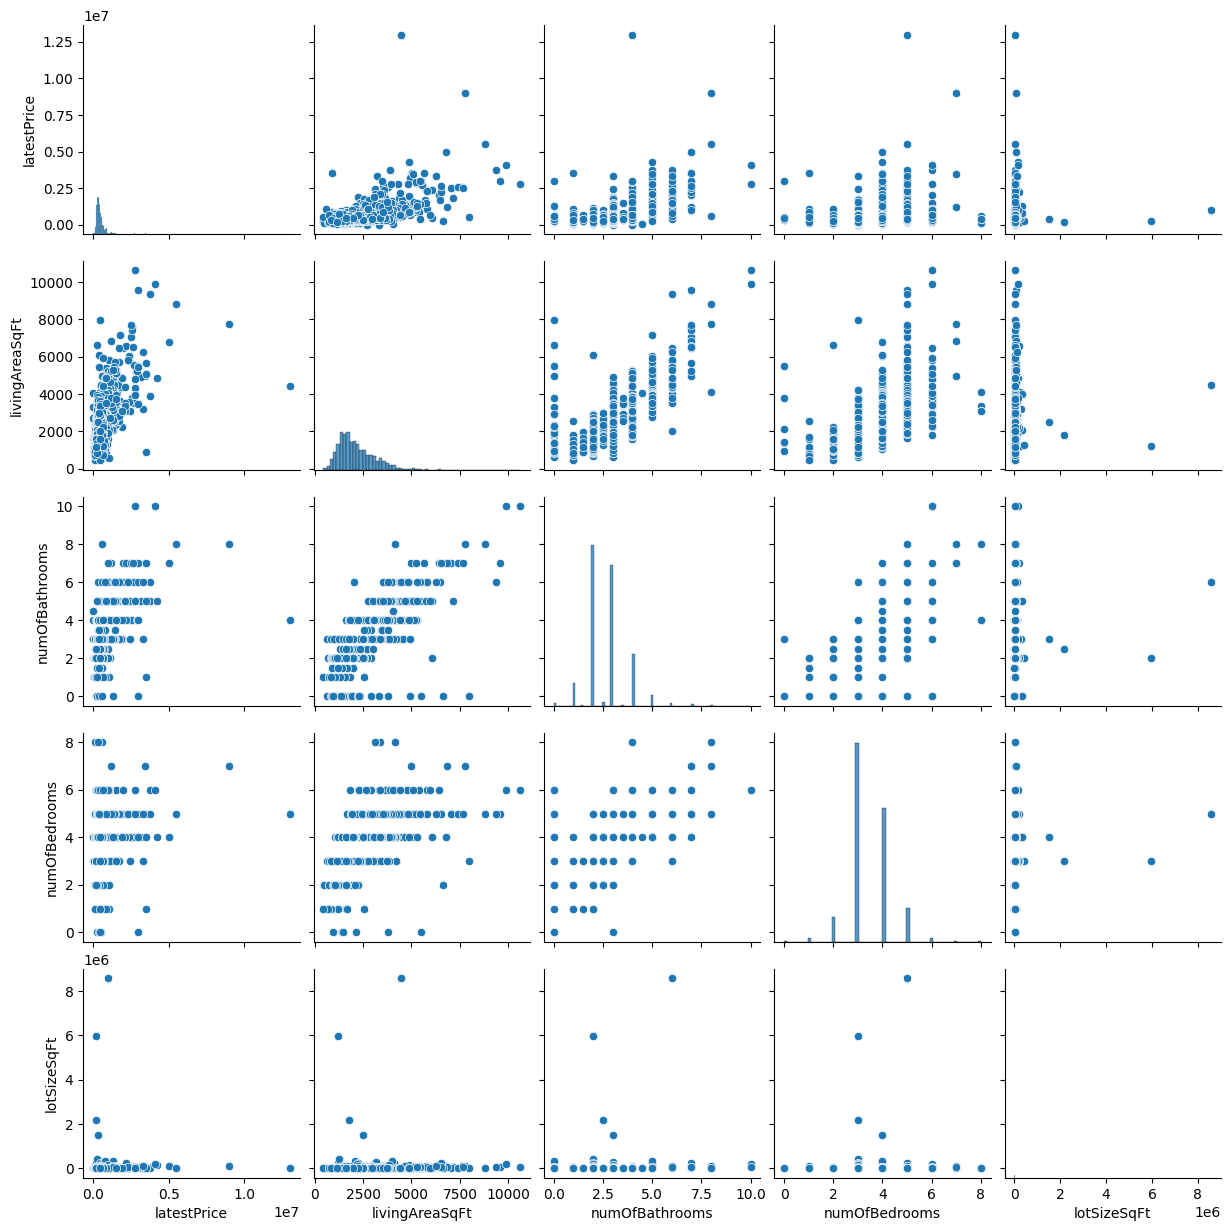

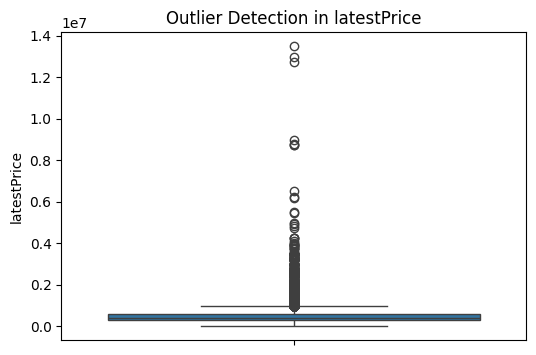

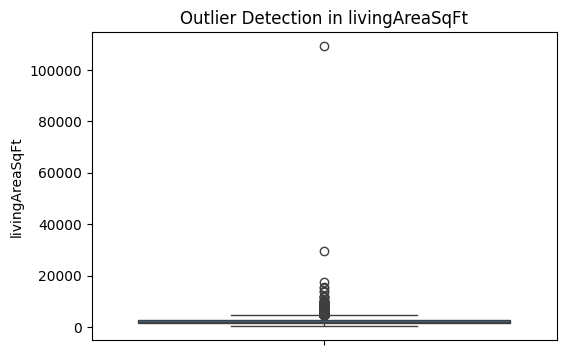

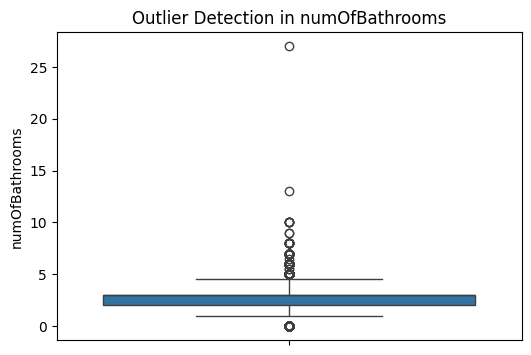

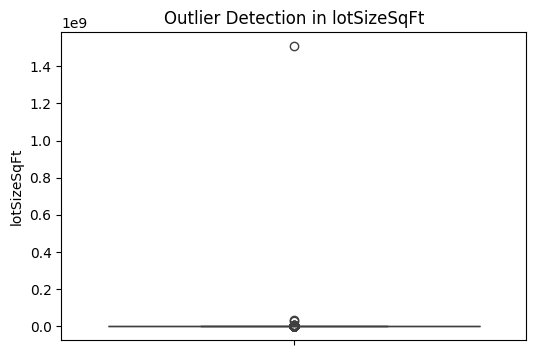


Potential Redundant Variables (Highly Correlated Features Above 0.7):
          Feature1                  Feature2  Correlation
1    parkingSpaces              garageSpaces     0.997321
2  avgSchoolRating  MedianStudentsPerTeacher     0.734615


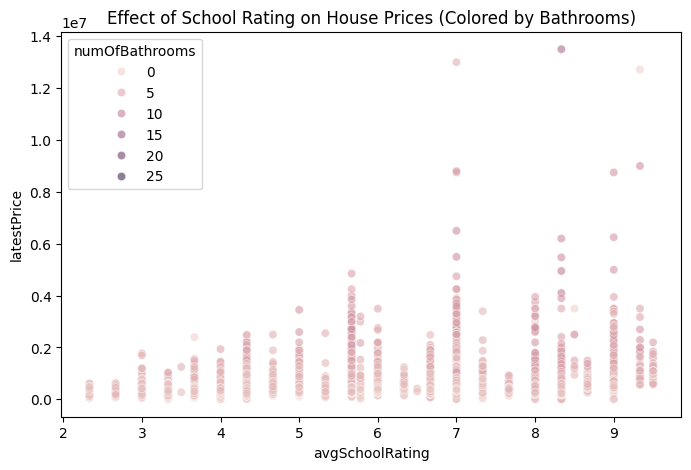

In [6]:
# Drop non-numeric columns to avoid errors in correlation calculations
df_numeric = df.select_dtypes(include=['number'])

# 1. Compute Correlation Matrix (Select Key Correlations)
corr_matrix = df_numeric.corr()

# Find highly correlated variable pairs (above 0.7 but less than 1 to avoid self-correlation)
high_corr_pairs = (
    corr_matrix.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .reset_index()
)
high_corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_pairs = high_corr_pairs[
    (high_corr_pairs["Correlation"] > 0.7) & (high_corr_pairs["Correlation"] < 1)
]
print("\nHighly Correlated Variable Pairs (Above 0.7):")
print(high_corr_pairs)

# 2. Scatterplots for Highly Correlated Features (Select Top 3)
top_corr_features = high_corr_pairs.head(3)
for index, row in top_corr_features.iterrows():
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[row["Feature1"]], y=df[row["Feature2"]])
    plt.title(f"Scatterplot of {row['Feature1']} vs {row['Feature2']}")
    plt.show()

# 3. Pairplot for the Most Relevant Features (Downsampled)
relevant_features = ["latestPrice", "livingAreaSqFt", "numOfBathrooms", "numOfBedrooms", "lotSizeSqFt"]
df_sampled = df_numeric[relevant_features].sample(frac=0.2, random_state=42)  # Use only 20% to avoid memory overload
sns.pairplot(df_sampled)
plt.show()

# 4. Line Plot for Trends Over Time (if 'date' exists)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

    plt.figure(figsize=(12, 5))
    df.resample("M").mean()["latestPrice"].plot(title="Average House Price Over Time")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.show()

# 5. Outlier Detection (Boxplots for Key Features)
key_outlier_features = ["latestPrice", "livingAreaSqFt", "numOfBathrooms", "lotSizeSqFt"]
for feature in key_outlier_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, y=feature)
    plt.title(f"Outlier Detection in {feature}")
    plt.show()

# 6. Checking for Redundant Variables
print("\nPotential Redundant Variables (Highly Correlated Features Above 0.7):")
print(high_corr_pairs)

# 7. Confounding Variable Analysis: Example of School Ratings & Housing Prices
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="avgSchoolRating", y="latestPrice", hue="numOfBathrooms", alpha=0.6)
plt.title("Effect of School Rating on House Prices (Colored by Bathrooms)")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

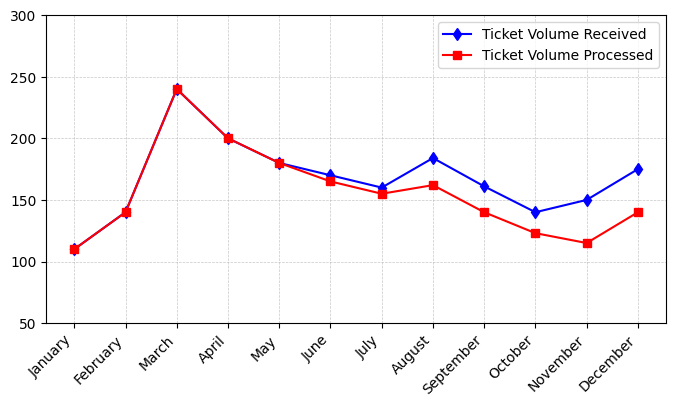

In [20]:

months = ["January", "February", "March", "April", "May", "June", 
          "July", "August", "September", "October", "November", "December"]
ticket_received = [110, 140, 240, 200, 180, 170, 160, 184, 161, 140, 150, 175]
ticket_processed = [110, 140, 240, 200, 180, 165, 155, 162, 140, 123, 115, 140]


plt.figure(figsize=(8, 4))

# Plot ticket volume received (blue line with diamond markers)
plt.plot(months, ticket_received, marker='d', linestyle='-', color='blue', label="Ticket Volume Received")

# Plot ticket volume processed (red line with square markers)
plt.plot(months, ticket_processed, marker='s', linestyle='-', color='red', label="Ticket Volume Processed")

plt.xticks(rotation=45, ha="right") 
plt.yticks(range(50, 301, 50))  
plt.ylim(50, 300)  
plt.xlabel("")  
plt.ylabel("")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()
plt.show()
